# **Lab 4: Numerical Integration and Algorithm Accuracy**

---
## **Introduction: Why a "Better" Algorithm Matters**

Last week, we successfully modeled the three-body problem using the **momentum principle**. The update rule we used was straightforward and effective:

1.  Calculate the net force $\vec{F}_{net}$ at the object's current position.
2.  Update the momentum over the time step $dt$: $\vec{p}_{new} = \vec{p}_{old} + \vec{F}_{net} \cdot dt$.
3.  Update the position using that **new** momentum: $\vec{r}_{new} = \vec{r}_{old} + (\vec{p}_{new}/m) \cdot dt$.

This powerful and stable method is known as the **Euler-Cromer** (or semi-implicit Euler) algorithm. The key to its success is using the *updated* momentum to calculate the new position.


You might wonder, are there other ways to do this? And if so, why bother if this one works? While Euler-Cromer is a huge improvement over the most basic algorithm, it still has limitations in accuracy. For long-term simulations where precision is critical (like predicting a satellite's position years from now), even small errors can accumulate into large ones.

In this lab, we will compare the Euler-Cromer method you've already built with two other algorithms: the less accurate **Forward Euler** method (to see why the "Cromer" part is so important) and the highly accurate **Runge-Kutta (RK4)** method. Finally, we will see how we can use the SciPy library to model this problem.



## **Part 1: A More Powerful Formulation with State Vectors**

---
### **Why Are We Doing This?**

So far in these labs, we have mixed our physics calculations (forces, momentum updates) directly inside the main simulation loop. This works perfectly well, but in professional scientific computing, it's more common separate the **physics rules** from the **integration algorithm**.

We can achieve this by creating:
1.  A single **state vector** (`s`) that holds all the information about our system at one instant.
2.  A single **derivative function** (`derivs`) that contains all the physics. This function's only job is to calculate the rate of change of the state vector.


***Note that in differential calculus, we often see the dependent variable  called `y` from $\frac{dy}{dt}=f(t,y)$*** We are avoing this so that we don't get `y` confused with the coordinate $y$.

This approach is incredibly powerful. It turns our physics model into a modular "engine." We can then plug this engine into any integration "chassis" we want—be it Euler-Cromer, RK4, or a high-precision solver from a library like SciPy—without changing the physics code at all.


---
### **1. Defining the State Vector (`s`)**

A **state vector** is a 1D array that contains every variable needed to completely describe the system. For our problem, we need the positions and momenta of the two moving bodies (Moon and spacecraft). We will "flatten" them into a single, consistent order:

$ s = [x_{moon}, y_{moon}, x_{craft}, y_{craft}, p_{x,moon}, p_{y,moon}, p_{x,craft}, p_{y,craft}] $

This is a NumPy array with 8 elements. As long as we always use this order, we can represent the entire state of our simulation at any time `t` with this one vector.

---
### **2. The Derivative Function: `ds/dt = f(t, s)`**

The core of this new method is a single function that represents all the laws of motion. This function takes the state vector `s` at time `t` and returns its time derivative, `ds/dt`.

The derivative vector must have the exact same shape and order as the state vector:
$\frac{ds}{dt} = [\frac{dx_m}{dt}, \frac{dy_m}{dt}, \frac{dx_c}{dt}, \frac{dy_c}{dt}, \frac{dp_{xm}}{dt}, \frac{dp_{ym}}{dt}, \frac{dp_{xc}}{dt}, \frac{dp_{yc}}{dt}]$

We know from physics how to calculate these rates of change:
* **Rate of change of position:** $\frac{d\vec{r}}{dt} = \frac{\vec{p}}{m}$
* **Rate of change of momentum:** $\frac{d\vec{p}}{dt} = \vec{F}_{net}$

Our derivative function will simply apply these rules.


### **Your Task: Create the Derivative Function and Initial State**

Your goal is to implement the `deriv_3body` function and the initial state vector `s0`.

### **Task 1: Create the initial state vector `s0`**
Using your initial conditions from Part 1 of the lab, create a single NumPy array called `s0` that follows the state vector structure defined above.

### **Task 2: Complete the `deriv_3body` function**
Below is the skeleton for the derivative function. Complete the code following the comments. The logic follows a standard and reusable pattern: **Unpack -> Calculate -> Repack**.

```python

#imports

#constants
# Physical Constants
G = 6.67430e-11      # N m^2 / kg^2
mEarth = 5.972e24    # kg
mMoon = 7.342e22     # kg
mCraft = 2000        # kg
earth_pos = np.array([0.0, 0.0]) # Earth is fixed at the origin

# Simulation Parameters
t_final = 3600 * 24 * 30 # Total simulation time in seconds (30 days)
dt = 60.0                # Time step in seconds

# --- Task 1: Create the Initial State Vector s0 ---
# Initial positions (m)
r_moon_initial = #
r_craft_initial = #

# Initial velocities (m/s)
v_moon_initial = #
v_craft_initial = #

# Convert velocities to momenta (p = mv)
p_moon_initial =#
p_craft_initial = #

# Assemble the initial state vector s0
# Order: [x_m, y_m, x_c, y_c, p_mx, p_my, p_cx, p_cy]
s0 = np.concatenate([r_moon_initial, r_craft_initial, p_moon_initial, p_craft_initial])


###make the state vector




# --- Task 2: Complete the Derivative Function ---

def deriv_3body(t, s):
    """
    Calculates the time derivative of the state vector for the 3-body problem.
    """
    # 1. UNPACK the state vector `s` into meaningful variables
    r_moon = s[0:2]
    r_craft = s[2:4]
    p_moon = s[4:6]
    p_craft = s[6:8]

    # 2. CALCULATE the net forces on the Moon and the spacecraft.
    #    (This is where the students add their physics code)
    # ... your code here ...
    # F_earth_on_moon = ...
    # F_earth_on_craft = ...
    # F_moon_on_craft = ...

    # 3. CALCULATE the derivatives
    # dr/dt = p/m
    dr_moon_dt = p_moon / mMoon
    dr_craft_dt = p_craft / mCraft
    
    # dp/dt = F_net
    # ... your code here ...
    # dp_moon_dt = ...
    # dp_craft_dt = ...

    # 4. REPACK the derivatives into a single array in the correct order
    ds_dt = np.concatenate([dr_moon_dt, dr_craft_dt, dp_moon_dt, dp_craft_dt])
    
    return ds_dt

In [ ]:
#Write your code here

import numpy as np
import matplotlib.pyplot as plt
#Write your code here# imports

# constants
# Physical Constants
G = 6.67430e-11      # N m^2 / kg^2
mEarth = 5.972e24    # kg
mMoon = 7.342e22     # kg
mCraft = 2000        # kg
earth_pos = np.array([0.0, 0.0]) # Earth is fixed at the origin

# Simulation Parameters
t_final = 3600 * 24 * 30 # Total simulation time in seconds (30 days)
dt = 60.0                # Time step in seconds

# --- Task 1: Create the Initial State Vector s0 ---
# Initial positions (m)
r_moon_initial = np.array([3.844e8, 0])
r_craft_initial = np.array([-1e8, 0])

# Initial velocities (m/s)
v_moon_initial = np.array([0,np.sqrt(G*mEarth/np.linalg.norm(r_moon_initial))])#
v_craft_initial = np.array([0,np.sqrt(G*mEarth/np.linalg.norm(r_craft_initial))])##

# Convert velocities to momenta (p = mv)
p_moon_initial = mMoon*v_moon_initial
p_craft_initial = mCraft*v_craft_initial

# Assemble the initial state vector s0
# Order: [x_m, y_m, x_c, y_c, p_mx, p_my, p_cx, p_cy]
s0 = np.concatenate([r_moon_initial, r_craft_initial, p_moon_initial, p_craft_initial])


### make the state vector
s = s0.copy()


# --- Task 2: Complete the Derivative Function ---

def deriv_3body(t, s):
    """
    Calculates the time derivative of the state vector for the 3-body problem.
    """
    # 1. UNPACK the state vector `s` into meaningful variables
    r_moon = s[0:2]
    r_craft = s[2:4]
    p_moon = s[4:6]
    p_craft = s[6:8]

    # 2. CALCULATE the net forces on the Moon and the spacecraft.
    #    (This is where the students add their physics code)
    # ... your code here ...
    F_earth_on_moon = -G*mEarth*mMoon/np.linalg.norm(r_moon)**3*r_moon
    F_earth_on_craft = -G*mEarth*mCraft/np.linalg.norm(r_craft)**3*r_craft
    F_moon_on_craft = -G*mMoon*mCraft/np.linalg.norm(r_craft-r_moon)**3*(r_craft-r_moon)

    # 3. CALCULATE the derivatives
    # dr/dt = p/m
    dr_moon_dt = p_moon / mMoon
    dr_craft_dt = p_craft / mCraft

    # dp/dt = F_net
    # ... your code here ...
    dp_moon_dt = F_earth_on_moon - F_moon_on_craft
    dp_craft_dt = F_earth_on_craft + F_moon_on_craft

    # 4. REPACK the derivatives into a single array in the correct order
    ds_dt = np.concatenate([dr_moon_dt, dr_craft_dt, dp_moon_dt, dp_craft_dt])

    return ds_dt


---
## **Part 2: Meet the Algorithms**

We will compare three different strategies for advancing our simulation. Each method takes the current state vector $\vec{s}(t)$ and calculates the state at the next time step, $\vec{s}(t+dt)$. They all rely on a single **derivative function**, let's call it `derivs(t, s)`, which contains the physics and returns the time derivative of the state, $d\vec{s}/dt$.

### **1. The (Forward) Euler Method**
This is the most direct translation of a derivative into an algorithm. It calculates the slope (the derivative) at the beginning of the step and uses that single value to project forward.

* Calculate the derivative of the state at the current time:
    $\frac{d\vec{s}}{dt} = \text{derivs}(t, \vec{s}(t))$
* Update the entire state vector in one go:
    $\vec{s}(t+dt) = \vec{s}(t) + \frac{d\vec{s}}{dt} \cdot dt$

The fatal flaw is that this uses the rates of change from the *start* of the step for the whole step. This leads to a systematic error that continuously adds energy to an orbit, causing it to spiral outwards.

---
### **2. The Euler-Cromer Method**
This method is more specialized. It "knows" that the state vector $\vec{s}$ contains both positions and momenta, and it treats them in a specific sequence. It is not a general-purpose integrator; it is designed for mechanics problems.

The update cannot be written as a single line. Instead, it proceeds in two steps:

1.  **Update Momentum First:** Calculate the derivative vector, but only use the force part (the rate of change of momentum) to update the momentum components of the state vector.
    * $\frac{d\vec{p}}{dt} = \vec{F}_{net}(\vec{r}(t))$
    * $\vec{p}(t+dt) = \vec{p}(t) + \frac{d\vec{p}}{dt} \cdot dt$

2.  **Update Position Second:** Now, use the **newly calculated** momentum to update the position components of the state vector.
    * $\vec{r}(t+dt) = \vec{r}(t) + \frac{\vec{p}(t+dt)}{m} \cdot dt$

This small change—using the updated momentum to find the new position—makes a world of difference. The energy error tends to oscillate around zero instead of growing indefinitely, leading to much more stable orbits.

---
### **3. The Runge-Kutta 4th Order (RK4) Method**
The RK4 method is a general-purpose integrator and a gold standard for scientific computing. It works beautifully with the state vector formulation. It samples the derivative at four different points within the time step to create a highly accurate weighted average.

Given the derivative function $\vec{f}(t, \vec{s}) = \text{derivs}(t, \vec{s})$:

1.  Calculate the slope at the start:
    $\vec{k}_1 = \vec{f}(t, \vec{s}(t))$
2.  Calculate a trial step to the midpoint and find the slope there:
    $\vec{k}_2 = \vec{f}(t + \frac{dt}{2}, \vec{s}(t) + \frac{dt}{2}\vec{k}_1)$
3.  Use $\vec{k}_2$  to make a more refined trial step to the midpoint and find the slope:

    $\vec{k}_3 = \vec{f}(t + \frac{dt}{2}, \vec{y}(t) + \frac{dt}{2}\vec{k}_2)$
4.  Use $\vec{k}_3$ to step all the way to the end and find the slope there:
    
    $\vec{k}_4 = \vec{f}(t + dt, \vec{s}(t) + dt \cdot \vec{k}_3)$
5.  Combine these slopes to make the final, highly accurate update:
    $\vec{s}(t+dt) = \vec{y}(t) + \frac{dt}{6}(\vec{k}_1 + 2\vec{k}_2 + 2\vec{k}_3 + \vec{k}_4)$

This requires four calls to your `derivs` function per time step, making it computationally "expensive." However, the accuracy gain is so enormous that you can often use a much larger time step $dt$ and still get a far superior result.

----
### **A Professional Solver (`scipy.integrate.solve_ivp`)**

---
## **Introduction: Beyond Fixed Steps**
So far, the algorithms we've written (Euler, Euler-Cromer, RK4) are all **fixed-step solvers**. We choose a single time step, `dt`, and use it for the entire simulation.

This is simple, but often inefficient. When our spacecraft is moving slowly in deep space, we could probably use a large `dt` without losing accuracy. But when it whips around the Moon in a close encounter, the forces change rapidly, and a very small `dt` is needed to model the physics correctly. A fixed-step method must use a small `dt` for the *entire* simulation just to handle the most intense parts, wasting computational effort.

Professional solvers use **adaptive stepping**. They automatically adjust the size of `dt` as they go:
* They take **small steps** when the physics is changing rapidly (high accelerations).
* They take **large steps** when the motion is smooth and predictable.

This provides the best of both worlds: high accuracy where it's needed and high efficiency everywhere else. We will use `scipy.integrate.solve_ivp`, a powerful adaptive solver, to generate a highly accurate "ground truth" solution to compare against.

---
## **Your Task: Using `solve_ivp` ⚙️**

Your task is to use `solve_ivp` to solve the 3-body problem and add its energy error to your final comparison plot. Because we already have our physics defined in the `deriv_3body` function, this is surprisingly easy.

The function needs four main things:
1.  Our derivative function (`deriv_3body`).
2.  The time interval to solve over (`t_span`).
3.  Our initial state vector (`s0`).
4.  Error tolerances (`rtol`, `atol`) which tell the solver how accurate the solution needs to be.

### **Implementation Steps**

1.  **Import the function:**
    `from scipy.integrate import solve_ivp`

2.  **Define the time span and call the solver:** The solver will run from `t=0` to `t=t_final`. We will set a tight relative tolerance (`rtol`) to get a very accurate solution.

    ```python
    # Define the time interval for the simulation
    t_span = [0, t_final]
    
    # Call the solver!
    # We pass it our derivative function, the time span, and our initial state.
    # We also give it a tight relative tolerance to ensure a high-quality result.
    solution = solve_ivp(deriv_3body, t_span, s0, method='RK45', rtol=1e-9)
    ```

3.  **Process the results:** The output `solution` object contains the times the solver chose (`solution.t`) and the state vectors at those times (`solution.s`). However, the shape of `solution.s` is `(8, num_steps)`. For our analysis and plotting, we need it to be `(num_steps, 8)`. We can fix this by transposing the array with `.T`.

    ```python
    # Get the time steps and transpose the solution array to the correct shape
    scipy_times = solution.t
    scipy_states = solution.sy.T # Don't forget the transpose!
    ```


In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
#continue your code here with some hints

# --- Stepper Functions for Different Algorithms ---

def euler_step(t, s, dt, derivs):
    """Takes one step using the Forward Euler method."""
    s_next = s + (derivs(t,s) * dt)
    return s_next

def euler_cromer_step(t, s, dt, derivs):
    """Takes one step using the Euler-Cromer method."""
    # This one is special because it needs to unpack, update p, then update r.
    r_moon = s[0:2]
    r_craft = s[2:4]
    p_moon = s[4:6]
    p_craft = s[6:8]

    # Calculate the derivative at the current state
    ds_dt = derivs(t, s)

    # Extract the force components (dp/dt)
    f_moon = ds_dt[4:6]
    f_craft = ds_dt[6:8]

    p_moon_next = p_moon + (f_moon * dt)
    p_craft_next = p_craft + (f_craft * dt)

    r_moon_next = r_moon + (p_moon_next * dt / mMoon)
    r_craft_next = r_craft + (p_craft_next * dt / mCraft)


    s_next = np.concatenate([r_moon_next, r_craft_next, p_moon_next, p_craft_next])
    return s_next

def rk4_step(t, s, dt, derivs):
    # 1. Calculate k1: The derivative at the start of the interval.
    k1 = derivs(t, s)

    # 2. Calculate k2: The derivative at the midpoint of the interval,
    #    using the k1 slope to estimate the state at the midpoint.
    midpoint_state_1 = s + 0.5 * dt * k1
    k2 = derivs(t + 0.5 * dt, midpoint_state_1)

    # 3. Calculate k3: A better estimate of the derivative at the midpoint,
    #    using the k2 slope to estimate the state at the midpoint.
    midpoint_state_2 = s + 0.5 * dt * k2
    k3 = derivs(t + 0.5 * dt, midpoint_state_2)

    # 4. Calculate k4: The derivative at the end of the interval,
    #    using the k3 slope to estimate the state at the end point.
    endpoint_state = s + dt * k3
    k4 = derivs(t + dt, endpoint_state)

    # 5. Combine the four derivatives in a weighted average to get the final state.
    s_next = s + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)
    return s_next

# --- Generic Simulation Loop ---

def run_simulation(s0, t_final, dt, derivs, stepper):
    """
    Runs a simulation using a given initial state and stepper function.
    """
    num_steps = int(t_final / dt)
    history = np.zeros((num_steps + 1, len(s0)))
    history[0] = s0

    s = s0.copy()
    for i in range(num_steps):
        t = i * dt
        s = stepper(t, s, dt, derivs)
        history[i+1] = s

    return history

# --- Run Simulations with All Methods ---

# Run your hand-coded integrators
history_euler = run_simulation(s0, t_final, dt, deriv_3body, euler_step)
history_cromer = run_simulation(s0, t_final, dt, deriv_3body, euler_cromer_step)
history_rk4 = run_simulation(s0, t_final, dt, deriv_3body, rk4_step)

# Run the professional SciPy solver
t_span = [0, t_final]
solution = solve_ivp(deriv_3body, t_span, s0, method='RK45', rtol=1e-9)
scipy_times = solution.t
scipy_states = solution.y.T

---
## **Part 3: How Do We Compare Them? Measuring Accuracy**

How do we prove that one algorithm is better than another?

### **1. Visual Inspection**
First, does the simulation look physically plausible? A stable orbit should not spiral away or decay into the Earth for no reason.
### **2. Conservation of Energy**
In a real, isolated system like a spacecraft orbiting the Earth and Moon, both total momentum and total mechanical energy are conserved. But for calculating accuracy of our algorithm, we use energy conservation because **energy is a far more sensitive and revealing test of an algorithm's accuracy for orbital problems.**

### **Why Momentum Isn't a Great Test Here**

The way we update momentum in our simulation is a very direct application of Newton's laws: $\vec{p}_{new} = \vec{p}_{old} + \vec{F}_{net} \cdot dt$.

For any two interacting bodies, the gravitational forces are equal and opposite ($\vec{F}_{A-on-B} = -\vec{F}_{B-on-A}$). Because of this perfect symmetry from Newton's Third Law, the internal forces within the system cancel out. This means that the total momentum of an isolated system is conserved almost perfectly by the very structure of the force calculation.

Since even a simple, flawed algorithm gets momentum right by default, checking it doesn't tell you much about how accurately the simulation is modeling the trajectory over time. It's a robust but **insensitive** measure of error.

### **Why Energy is a Perfect Test for Orbits**

Numerical errors in orbital simulations don't happen because the force is calculated wrong. They happen because we approximate a smooth, curved path with a series of short, straight-line steps. **Energy acts as a magnifying glass for these tiny geometric errors.**

1.  **Sensitivity to Position Error:** Total energy depends on both velocity squared ($p^2/2m$) and position ($-GMm/r$). A tiny error in the calculated position `r` at the end of a time step creates a noticeable error in the potential energy. This error then feeds back into the next step, accumulating over time.

2.  **Revealing Systematic Flaws:** The way an algorithm handles these small errors is unique, and plotting the energy makes these flaws obvious.
    * The **Forward Euler** method, for example, consistently takes steps that are slightly too far "outside" the true curved path. This causes both the potential and kinetic energy to increase slightly with each step, leading to a steady, artificial **gain in total energy**. The spacecraft spirals away in a physically impossible manner.



    * Better methods like **Euler-Cromer** and **Runge-Kutta** are designed to correct for this curvature. Their position errors don't accumulate in one direction. As a result, the calculated total energy oscillates around the true, constant value with a very small amplitude.

Plotting the relative energy error over time gives a clear, quantitative verdict on the quality of each algorithm. A line that steadily climbs or falls indicates a flawed method, while a line that stays flat and close to zero indicates a stable and accurate one.



In summary, momentum conservation is built into the force calculations, making it a robust but uninformative metric. **Energy conservation is delicate and highly sensitive to the position errors that separate a bad integrator from a good one**, making it the ideal diagnostic tool for orbital simulations.

###**Details**

The total energy is the sum of its kinetic energy (written in terms of momentum) and its gravitational potential energy from both the Earth and the Moon. At any given time step, you can calculate this from your **state vector** `s`:

$ E_{total} = KE_{craft} + GPE_{craft-Earth} + GPE_{craft-Moon} $

$ E_{total} = \frac{|\vec{p}_{craft}|^2}{2m_{craft}} - G\frac{M_{Earth}m_{craft}}{|\vec{r}_{craft-Earth}|} - G\frac{M_{Moon}m_{craft}}{|\vec{r}_{craft-Moon}|} $

A perfect integrator would keep $E_{total}$ exactly constant. In reality, all numerical methods will introduce small errors that cause the energy to fluctuate. A good algorithm is one that keeps these fluctuations extremely small.

To visualize this, we will plot the **relative energy error** over time:
$$ \text{Relative Error} = \frac{E(t) - E(0)}{|E(0)|} $$
A small, non-growing error that oscillates around zero indicates a stable and accurate algorithm. A large or steadily growing error signals a method that cannot be trusted for long-term predictions.

In the next part of the lab, you will implement these different update rules and generate energy error plots to see the difference firsthand.

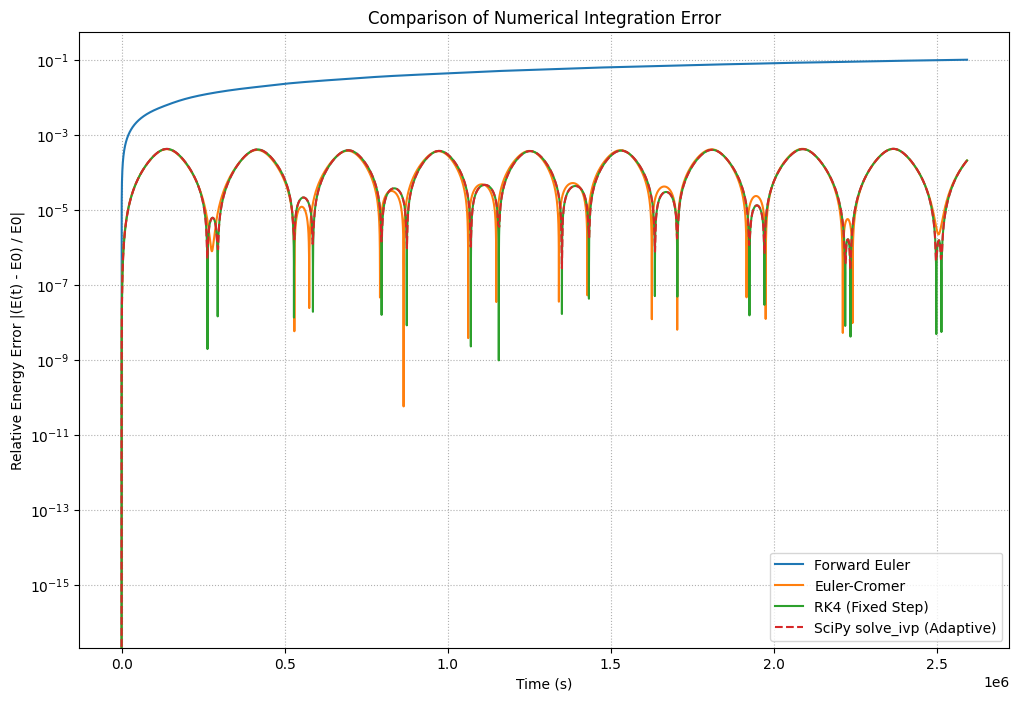

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
# --- Analysis: Calculate and Plot Energy Error ---

def calculate_spacecraft_energy(s):
    """Calculates the spacecraft's total energy from a state vector."""
    # ... your code here ...
    # Unpack, calculate KE, GPE_Earth, GPE_Moon, and return the sum.
    r_moon = s[0:2]
    r_craft = s[2:4]
    p_moon = s[4:6]
    p_craft = s[6:8]

    KEcraft = np.linalg.norm(p_craft)**2 / (2 * mCraft)
    GPEearth = -G * mEarth * mCraft / np.linalg.norm(r_craft)
    GPEmoon = -G * mMoon * mCraft / np.linalg.norm(r_craft - r_moon)
    E_total = KEcraft + GPEearth + GPEmoon
    return E_total

# Calculate the initial energy
E0 = calculate_spacecraft_energy(s0)

# Calculate the energy history for each simulation
energy_euler = np.array([calculate_spacecraft_energy(s) for s in history_euler])
energy_cromer = np.array([calculate_spacecraft_energy(s) for s in history_cromer])
energy_rk4 = np.array([calculate_spacecraft_energy(s) for s in history_rk4])
energy_scipy = np.array([calculate_spacecraft_energy(s) for s in scipy_states])

# Calculate the relative energy error
error_euler = abs((energy_euler - E0) / E0)
error_cromer = abs((energy_cromer - E0) / E0)
error_rk4 = abs((energy_rk4 - E0) / E0)
error_scipy = abs((energy_scipy - E0) / E0)

# --- Plotting ---
plt.figure(figsize=(12, 8))

times = np.arange(len(history_euler)) * dt

plt.plot(times, error_euler, label='Forward Euler')
plt.plot(times, error_cromer, label='Euler-Cromer')
plt.plot(times, error_rk4, label='RK4 (Fixed Step)')
plt.plot(scipy_times, error_scipy, label='SciPy solve_ivp (Adaptive)', linestyle='--')

# Use a logarithmic scale for the y-axis to see the huge differences!
plt.yscale('log')

plt.title('Comparison of Numerical Integration Error')
plt.xlabel('Time (s)')
plt.ylabel('Relative Energy Error |(E(t) - E0) / E0|')
plt.legend()
plt.grid(True, which='both', linestyle=':')
plt.show()

## Part 4:Questions


Please answer the following questions in a new markdown cell in your notebook.

---
### **Question 1: Interpreting the Results**
Include the final energy error plot you generated that compares all four methods (Forward Euler, Euler-Cromer, RK4, and `scipy.solve_ivp`).
* **Rank** the four algorithms from worst to best in terms of their ability to conserve energy in this simulation.
* **Quantify** the difference. Roughly by what factor is RK4 more accurate than Euler-Cromer? By what factor is `solve_ivp` more accurate than your RK4 implementation?

---
### **Question 2: The Euler vs. Euler-Cromer Difference**
The code to implement the Forward Euler and Euler-Cromer methods is almost identical—the only difference is whether you use the old or new momentum to update the position. Why does this tiny change have such a dramatic effect on the long-term stability and energy conservation of the orbit?

---
### **Question 3: Accuracy vs. Computational Cost**
The RK4 method was significantly more accurate than the Euler-Cromer method, but this accuracy comes at a price.
* How many times must your `deriv_3body` function be called to complete one time step `dt` for **Euler-Cromer** versus for **RK4**?
* Describe a hypothetical scenario (e.g., in video game physics, a weather simulation, etc.) where you might choose the "less accurate" Euler-Cromer method over the "more accurate" RK4. What would be the trade-off you are making?



# **Lab 5: Benchmarking - Accuracy vs. Speed**

---
## **Mission Objective**
We've seen that the RK4 method is far more accurate than Euler-Cromer, but we also reasoned that it must be slower because it does more work. In computational science, it's not enough to say something is "slower"; we need to measure it.

The process of formally measuring code performance is called **benchmarking**. A "better" algorithm is often the one that gives the most accuracy for the least amount of computational time.

**Your task:** Benchmark your `Euler-Cromer` and `RK4` simulations to measure their execution time. Then, create a plot that visualizes the trade-off between speed and accuracy.

---
## **Procedure**

1.  **Measure Execution Time:** We will use Python's built-in `time` module to measure how long each simulation takes to run. You simply record the time before you run the simulation and again after it finishes.

2.  **Quantify Accuracy:** We need a single number to represent the "accuracy" of each method. A good choice is the average energy error over the second half of the simulation.

3.  **Plot the Trade-off:** Create a scatter plot with the measured execution time on the x-axis and the average error on the y-axis. This will give you a direct visual comparison of the performance of each algorithm.

---
## **Deliverable**

1.  Create a new code cell and use the skeleton below to benchmark your functions and create the plot.
2.  Answer the question: **Based on your plot, which algorithm provides a better balance of accuracy and speed for this problem? If you needed a result with an error of about 1e-5, which method would you choose and why?**

### **Skeleton Code for Benchmarking**

```python
import time

# --- 1. Benchmark Euler-Cromer ---
print("Benchmarking Euler-Cromer...")
start_time_ec = time.time()
history_cromer = run_simulation(s0, t_final, dt, deriv_3body, euler_cromer_step)
end_time_ec = time.time()

# Calculate execution time
time_ec = end_time_ec - start_time_ec

# Calculate average error for the second half of the simulation
energy_cromer = np.array([calculate_spacecraft_energy(s) for s in history_cromer])
error_cromer = np.abs((energy_cromer - E0) / E0)
avg_error_ec = np.mean(error_cromer[len(error_cromer)//2:]) # Mean of the last half

print(f"Euler-Cromer took {time_ec:.4f} s with an average error of {avg_error_ec:.2e}")


# --- 2. Benchmark RK4 ---
print("Benchmarking RK4...")
start_time_rk4 = time.time()
# ... your code here to run the RK4 simulation ...
end_time_rk4 = time.time()

# Calculate execution time for RK4
# ... your code here ...

# Calculate average error for RK4
# ... your code here ...

print(f"RK4 took {time_rk4:.4f} s with an average error of {avg_error_rk4:.2e}")


# --- 3. Plot the results ---
plt.figure(figsize=(8, 6))

# Plot a point for each algorithm
plt.scatter(time_ec, avg_error_ec, s=100, label='Euler-Cromer')
plt.scatter(time_rk4, avg_error_rk4, s=100, label='RK4')

# Use a log scale for the y-axis (error)
plt.yscale('log')

plt.title('Accuracy vs. Performance of Integrators')
plt.xlabel('Execution Time (s)')
plt.ylabel('Average Relative Energy Error')
plt.legend()
plt.grid(True, which='both', linestyle=':')
plt.show()

Benchmarking Euler-Cromer...
Euler-Cromer took 1.5998 s with an average error of 1.45e-04
Benchmarking RK4...
RK4 took 5.5213 s with an average error of 1.42e-04


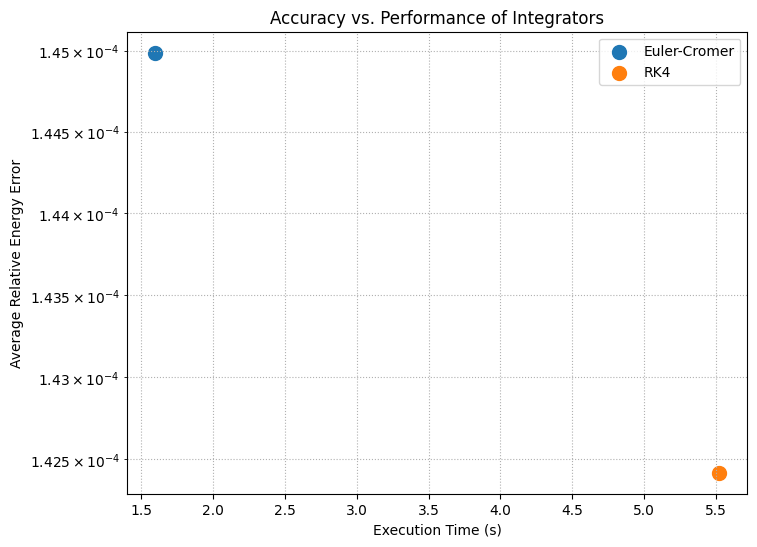

In [ ]:
import time

# --- 1. Benchmark Euler-Cromer ---
print("Benchmarking Euler-Cromer...")
start_time_ec = time.time()
history_cromer = run_simulation(s0, t_final, dt, deriv_3body, euler_cromer_step)
end_time_ec = time.time()

# Calculate execution time
time_ec = end_time_ec - start_time_ec

# Calculate average error for the second half of the simulation
energy_cromer = np.array([calculate_spacecraft_energy(s) for s in history_cromer])
error_cromer = np.abs((energy_cromer - E0) / E0)
avg_error_ec = np.mean(error_cromer[len(error_cromer)//2:]) # Mean of the last half

print(f"Euler-Cromer took {time_ec:.4f} s with an average error of {avg_error_ec:.2e}")


# --- 2. Benchmark RK4 ---
print("Benchmarking RK4...")
start_time_rk4 = time.time()
history_rk4 = run_simulation(s0, t_final, dt, deriv_3body, rk4_step)
end_time_rk4 = time.time()

# Calculate execution time for RK4
time_rk4 = end_time_rk4 - start_time_rk4

# Calculate average error for RK4
# ... your code here ...
energy_rk4 = np.array([calculate_spacecraft_energy(s) for s in history_rk4])
error_rk4 = np.abs((energy_rk4 - E0) / E0)
avg_error_rk4 = np.mean(error_rk4[len(error_rk4)//2:])

print(f"RK4 took {time_rk4:.4f} s with an average error of {avg_error_rk4:.2e}")

# --- 3. Plot the results ---
plt.figure(figsize=(8, 6))

# Plot a point for each algorithm
plt.scatter(time_ec, avg_error_ec, s=100, label='Euler-Cromer')
plt.scatter(time_rk4, avg_error_rk4, s=100, label='RK4')

# Use a log scale for the y-axis (error)
plt.yscale('log')

plt.title('Accuracy vs. Performance of Integrators')
plt.xlabel('Execution Time (s)')
plt.ylabel('Average Relative Energy Error')
plt.legend()
plt.grid(True, which='both', linestyle=':')
plt.show()